# MethaneSET · EMIT
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IPL-UV/taco-methaneset/blob/main/methaneset-codes/notebooks/03_emit.ipynb)

**Hyperspectral methane plume detection with NASA's EMIT (721 granules).**

What you will do here:
1. Open the collection and read its schema (one granule per sample, 10 sensor-geometry layers).
2. Explore the catalog: years, regions, emission rates, how many plumes per granule.
3. Look inside a granule: the 285-band radiance cube, the matched-filter products and the two
   **bitmask** plume masks (IMEO MARS and Carbon Mapper).
4. Decode a single plume out of the uint64 bitmask and crop the scene around it.
5. Measure the spatial agreement between the two independent annotations (IoU), and try a
   threshold baseline on the matched filter.

Data: `methaneset-emit` (721 granules: 700 with plumes + 21 verified plume-free), CC-BY-NC-SA-4.0.
See also: `01_s2`, `02_l89`, `04_bank`.

## 1. Setup
No credentials. `common.py` resolves the data (local folder or Hugging Face).

In [1]:
import os, urllib.request
if not os.path.exists("common.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/IPL-UV/taco-methaneset/main/methaneset-codes/notebooks/common.py",
        "common.py")
try:
    import tacoreader, rasterio
except ImportError:
    %pip install "tacoreader>=2.4,<3" rasterio matplotlib pandas pyarrow
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import rasterio
warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)
import common as C
C.style()
import tacoreader; print("tacoreader", tacoreader.__version__)

tacoreader 2.4.21


## 2. Load the collection
One row per EMIT granule; each sample holds ten rasters (`radiance`, `mf`, `rmf`, `mag1c`,
`plume_imeo`, `plume_cm`, `wind`, `latlon`, `glt`, `elevation`) in the sensor geometry.

In [2]:
ds = C.load("methaneset-emit")
df = ds.data.to_pandas()
print(df.shape[0], "granules |", len(df.columns), "columns")
print(sorted(df["selection:flux_bin"].unique()))

[common] methaneset-emit: local


721 granules | 66 columns
['free', 'has_weak', 'strong_only']


Columns are namespaced: `detection:` (annotations, flux and the bit→id maps),
`sensor:`/`spatial:`, `emit:` (acquisition times), `selection:` (flux class), `site:`.
The masks are **uint64 bitmasks**: one bit per annotated plume (see section 5).

In [3]:
df[["id", "site:country", "selection:flux_bin", "detection:n_imeo", "detection:n_cm",
    "detection:imeo_flux_max", "spatial:imeo_points"]].head(3)

,id,site:country,selection:flux_bin,detection:n_imeo,detection:n_cm,detection:imeo_flux_max,spatial:imeo_points
0,EMIT_L1B_RAD_001_20220810T064957_2222205_033,Israel,strong_only,1,1,2754.0,MULTIPOINT (35.20243 31.13423)
1,EMIT_L1B_RAD_001_20220810T065132_2222205_041,Syrian Arab Republic,strong_only,4,5,5221.0,"MULTIPOINT (40.44282 35.30753, 40.61051 35.091..."
2,EMIT_L1B_RAD_001_20220814T051412_2222604_005,Syrian Arab Republic,strong_only,1,3,1765.0,MULTIPOINT (41.13845 34.89365)


## 3. Overview: the catalog alone answers most questions

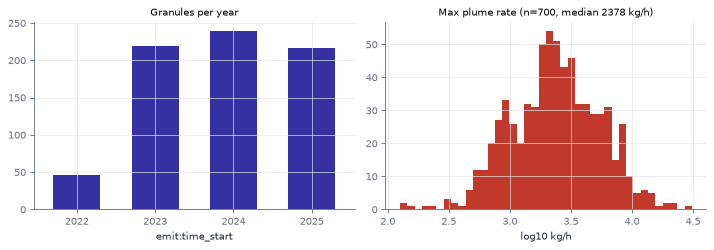

In [4]:
f = df
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
pd.to_datetime(f["emit:time_start"]).dt.year.value_counts().sort_index().plot.bar(
    ax=ax[0], color=C.PALETTE["emit"], width=0.6)
ax[0].set_title("Granules per year", fontsize=9); ax[0].tick_params(axis="x", rotation=0)
fl = pd.to_numeric(f["detection:imeo_flux_max"], errors="coerce").dropna()
ax[1].hist(np.log10(fl), bins=40, color=C.PALETTE["ch4"])
ax[1].set_title(f"Max plume rate (n={len(fl)}, median {fl.median():.0f} kg/h)", fontsize=9)
ax[1].set_xlabel("log10 kg/h"); fig.tight_layout(); plt.show()

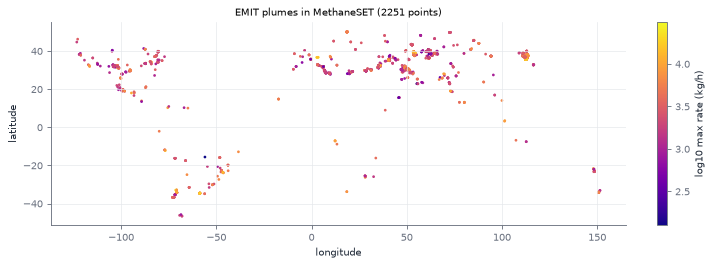

In [5]:
# where the IMEO plumes are (their coordinates live in the catalog, nothing to open)
import re
def points(txt):
    m = re.findall(r"(-?\d+\.\d+) (-?\d+\.\d+)", str(txt))   # handles MULTIPOINT too
    return [(float(a), float(b)) for a, b in m] or [(np.nan, np.nan)]
expl = f["spatial:imeo_points"].map(points).explode()
lon = np.array([p[0] for p in expl]); lat = np.array([p[1] for p in expl])
keep = np.isfinite(lon) & np.isfinite(lat)
lon, lat = lon[keep], lat[keep]; expl = expl[keep]
flux = np.log10(pd.to_numeric(f.loc[expl.index, "detection:imeo_flux_max"], errors="coerce").to_numpy())
fig, ax = plt.subplots(figsize=(9, 3.4))
sc = ax.scatter(lon, lat, s=6, c=flux, cmap=C.CMAP_ENH, linewidths=0)
fig.colorbar(sc, ax=ax, fraction=0.02, label="log10 max rate (kg/h)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"EMIT plumes in MethaneSET ({len(lon)} points)", fontsize=9)
fig.tight_layout(); plt.show()

## 4. Anatomy of a granule
The radiance cube has **285 bands** (381-2493 nm, ~7.4 nm). It is a cloud-optimized GeoTIFF, but the
useful economy is **spatial**, not spectral: read the plume mask, take its bounding box and only
then read the radiance crop (a few MB instead of the full granule). Band wavelengths follow the
standard EMIT grid: `C.emit_band(643)` gives the 1-based index of the 643 nm band (the RGB tuple
passed to `C.to_rgb` is 0-based over the stack).

In [6]:
# the granule with the strongest plume: read the mask first, then only the radiance window
f = df
idx = f.sort_values("detection:imeo_flux_max", ascending=False).index[0]
s = ds.read(int(idx)); row = f.loc[idx]
mask = C.read(s, "plume_imeo.tif", bands=1)
rs, cs = C.crop_around(mask, pad=60)
rad = C.read(s, "radiance.tif", window=(rs, cs))     # (285, h, w): a small crop
print("country:", row["site:country"], "| max IMEO rate:", round(float(row["detection:imeo_flux_max"])), "kg/h")
print("radiance window:", rad.shape, rad.dtype, "of a (285, 1280, 1242) cube")

country: Algeria | max IMEO rate: 30889 kg/h
radiance window: (285, 892, 746) float32 of a (285, 1280, 1242) cube


## 5. The plume masks are bitmasks
`plume_imeo.tif` and `plume_cm.tif` are **uint64**: every annotated plume owns one bit and a pixel
is the OR of the bits of all plumes covering it (that is how overlapping or nested annotations
survive). The per-granule maps `detection:imeo_bits` / `detection:cm_bits` translate bit → plume id,
and `plume_imeo.tif` carries a second band (`sources`) identifying which plumes touch each pixel.

In [7]:
import json
print("dtype:", mask.dtype, "| pixels with any plume:", int((mask != 0).sum()))
bits = json.loads(row["detection:imeo_bits"])
print("IMEO annotated plumes:", len(bits), "| bits:", list(bits)[:6])
one = C.bit_layer(mask, 1)           # first plume only
print("bit 1 plume -> pixels:", int(one.sum()), "| id:", bits["1"])

dtype: uint64 | pixels with any plume: 5382
IMEO annotated plumes: 2 | bits: ['1', '2']
bit 1 plume -> pixels: 3854 | id: DZA_S_024


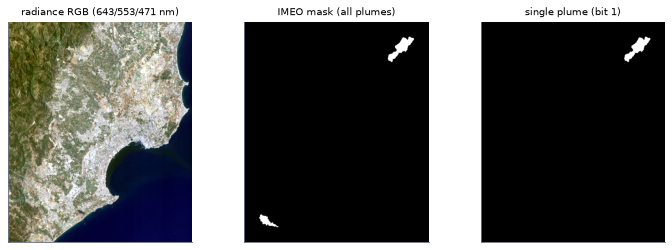

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
ax[0].imshow(C.to_rgb(rad, (35, 23, 12)))
ax[0].set_title("radiance RGB (643/553/471 nm)", fontsize=9)
ax[1].imshow(mask[rs, cs] != 0, cmap="gray"); ax[1].set_title("IMEO mask (all plumes)", fontsize=9)
ax[2].imshow(one[rs, cs], cmap="gray"); ax[2].set_title("single plume (bit 1)", fontsize=9)
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

## 6. Matched-filter products
Every granule ships three precomputed retrievals: the standard matched filter (`mf`), an
albedo-corrected single-pass `rmf`, and the iterative sparse `mag1c`. They are column enhancement
maps in ppm m and are what a retrieval-based pipeline (or a segmentation model) would consume.

mf over plume  : median 1109.7 ppm m
mf off plume   : median 0.0 ppm m


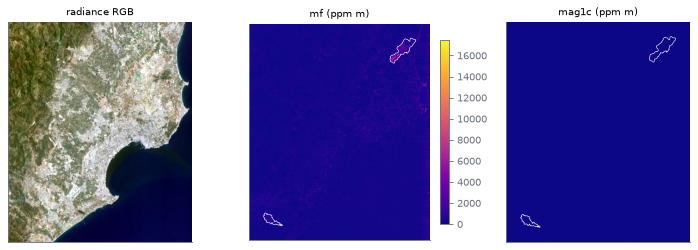

In [9]:
mf = C.read(s, "mf.tif", bands=1, window=(rs, cs))       # only the plume window
mc = mask[rs, cs] != 0
print("mf over plume  : median %.1f ppm m" % np.nanmedian(mf[mc]))
print("mf off plume   : median %.1f ppm m" % np.nanmedian(mf[~mc]))
fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
for a, layer, t in [(ax[0], C.to_rgb(rad, (35, 23, 12)), "radiance RGB"),
                    (ax[1], mf, "mf (ppm m)"), (ax[2], C.read(s, "mag1c.tif", bands=1, window=(rs, cs)), "mag1c (ppm m)")]:
    im = a.imshow(layer, cmap=None if "RGB" in t else C.CMAP_ENH)
    if "RGB" not in t: a.contour(mc, levels=[0.5], colors="w", linewidths=0.5)
    a.set_title(t, fontsize=9); a.set_xticks([]); a.set_yticks([])
fig.colorbar(ax[1].images[0], ax=ax[1], fraction=0.046)
fig.tight_layout(); plt.show()

## 7. Agreement between the two independent annotations
Both IMEO MARS and Carbon Mapper annotated the same granules, so we can measure how much their
segmentation masks overlap (intersection over union, IoU) granule by granule. We take a random
sample of 120 granules so the number is not tied to the catalog order. This is the slowest cell
here: it reads the full uint64 masks of the 120 granules (windowed reads would be cheaper).

granules with both masks: 118 of a random 120 | median IoU 0.34 | p25 0.17 | p75 0.48


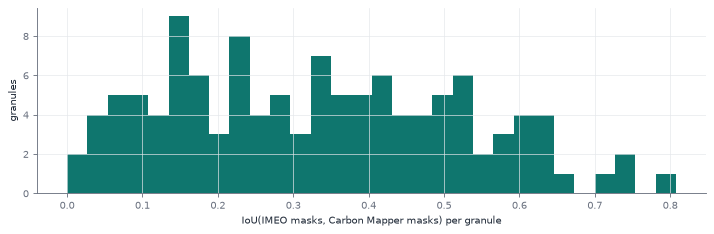

In [10]:
sample = df.sample(120, random_state=0).index
ious = []
for i in sample:
    sx = ds.read(int(i))
    a = C.read(sx, "plume_imeo.tif", bands=1) != 0
    b = C.read(sx, "plume_cm.tif", bands=1) != 0
    if a.any() and b.any():
        ious.append(C.seg_metrics(a, b)["iou"])
ious = np.array(ious)
print("granules with both masks: %d of a random 120 | median IoU %.2f | p25 %.2f | p75 %.2f" % (
    len(ious), np.median(ious), np.percentile(ious, 25), np.percentile(ious, 75)))
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.hist(ious, bins=30, color=C.PALETTE["imeo"])
ax.set_xlabel("IoU(IMEO masks, Carbon Mapper masks) per granule"); ax.set_ylabel("granules")
fig.tight_layout(); plt.show()

## 8. A minimal baseline on the matched filter
The simplest honest baseline: threshold the precomputed `mf` and compare with the IMEO mask. It is
computed inside the plume crop, so it is optimistic relative to a threshold chosen on a whole granule.

In [11]:
thr = np.nanpercentile(mf, 99)
m = C.seg_metrics(mf > thr, mc)
print("mf > p99  ->  IoU %.3f | precision %.3f | recall %.3f" % (m["iou"], m["precision"], m["recall"]))
for q in (95, 98, 99, 99.5):
    mm = C.seg_metrics(mf > np.nanpercentile(mf, q), mc)
    print(f"  p{q}: IoU {mm['iou']:.3f}  P {mm['precision']:.3f}  R {mm['recall']:.3f}")

mf > p99  ->  IoU 0.116 | precision 0.188 | recall 0.233
  p95: IoU 0.071  P 0.077  R 0.473
  p98: IoU 0.103  P 0.131  R 0.323
  p99: IoU 0.116  P 0.188  R 0.233


  p99.5: IoU 0.109  P 0.258  R 0.159


## 9. Wrap-up
- The catalog alone answers most questions; `detection:imeo_bits`/`cm_bits` translate every bit of
  the uint64 masks to a plume id, and `spatial:imeo_points` lists their coordinates (a granule can
  carry several plumes, hence MULTIPOINT).
- Reading is cheap if you ask for a spatial window: a crop of the plume box is a few MB instead of
  the full 285-band granule.
- The two annotations are independent segmentations, so their IoU (median 0.34 on a random sample)
  mixes missed pairs with genuine extent disagreement and understates the detection agreement.
- The matched filter is a useful feature, but a plain percentile threshold is a weak detector
  (IoU 0.12 at p99 above): it needs a learned segmentation on top.

Next: `01_s2`, `02_l89`, `04_bank`. Website: https://ipl-uv.github.io/taco-methaneset

```bibtex
@article{contreras2026methaneset,
  title   = {MethaneSET: Unified Multi-Sensor AI-Ready Datasets for
             Satellite-Based Methane Plume Detection},
  author  = {Contreras, Julio and Giner, Carlos and Aybar, Cesar
             and Mateo-Garcia, Gonzalo and Gorrono, Javier
             and Montero, David and Mahecha, Miguel D.
             and Guanter, Luis and Gomez-Chova, Luis},
  journal = {Scientific Data},
  year    = {2026}
}
```